# 01 — Exploratory Data Analysis

This notebook focuses on understanding the data and identifying the relationships that may be useful for modelling:
- the distribution of wins
- how season length changes across the dataset
- the relationship between scoring, run prevention and winning
- Pythagorean expectation
- changes in the run environment over time
- correlations among the main baseball statistics

The final target is still `W` (season wins). `Win_pct` is only used here to make seasons of different lengths easier to compare.


## 1. Load Data

In [1]:
# Load libraries and shared project configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from moneyball import project_config as cfg

# ---------------------------------------------------------------------
# Load shared project configuration
# ---------------------------------------------------------------------
cfg.configure_notebook()

# ---------------------------------------------------------------------
# Load source datasets
# ---------------------------------------------------------------------

train = pd.read_csv(cfg.TRAIN_PATH)
pred = pd.read_csv(cfg.PRED_PATH)


# ---------------------------------------------------------------------
# Traceability
# ---------------------------------------------------------------------
print("Project root:", cfg.PROJECT_ROOT)
print("Train shape :", train.shape)
print("Pred shape  :", pred.shape)

display(train.head(3))


Project root: /home/shpang/devs/ntu/projects/baseball_v2
Train shape : (1812, 52)
Pred shape  : (453, 48)


,yearID,teamID,G,R,AB,H,2B,3B,HR,BB,SO,SB,RA,ER,ERA,CG,SHO,SV,IPouts,HA,HRA,BBA,SOA,E,DP,FP,mlb_rpg,era_1,era_2,era_3,era_4,era_5,era_6,era_7,era_8,decade_1910,decade_1920,decade_1930,decade_1940,decade_1950,decade_1960,decade_1970,decade_1980,decade_1990,decade_2000,decade_2010,W,ID,year_label,decade_label,win_bins,franchID
0,1935,BOS,154,718,5288,1458,281,63,69,609,470.0,91,732,619,4.05,82,6,11,4128,1520,67,520,470,190,136.0,0.969,4.864690,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,78,317,1935,1930s,3,BOS
1,1993,TEX,162,835,5510,1472,284,39,181,483,984.0,113,751,684,4.28,20,6,45,4314,1476,144,562,957,130,145.0,0.979,4.597620,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,86,2162,1993,1990s,3,TEX
2,2016,SEA,162,768,5583,1446,251,17,223,506,1288.0,56,707,647,4.00,2,8,49,4371,1410,213,460,1318,89,158.0,0.985,4.477759,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,86,1895,2016,2010s,3,SEA


### Key fields

These are the main columns used in the analysis:

| Column | Meaning |
|---|---|
| `W` | Season wins |
| `G` | Games played |
| `R` | Runs scored |
| `RA` | Runs allowed |
| `HR` | Home runs |
| `ERA` | Earned run average |
| `HA` | Hits allowed |
| `HRA` | Home runs allowed |
| `BBA` | Walks allowed |
| `FP` | Fielding percentage |
| `yearID` | Season year |
| `teamID` / `franchID` | Team and franchise identifiers |

`ID` is only used to identify a row and will not be used as a model feature.


## 2. Wins and season length

The dataset covers a long period of baseball history, so teams did not always play the same number of games. This matters because a raw win total is partly affected by schedule length.

**Rsolution:** use win percentage here as a comparison measure, but the model will still predict total wins.


In [2]:
# Create a working copy and calculate win percentage
eda = train.copy()

eda["Win_pct"] = eda["W"] / eda["G"]

target_summary = eda[["W", "G", "Win_pct"]].describe().T
display(target_summary)

print("Unique season lengths:", eda["G"].nunique())
print(
    "Games played range:",
    int(eda["G"].min()),
    "to",
    int(eda["G"].max()),
)


,count,mean,std,min,25%,50%,75%,max
W,1812.0,79.261589,13.127166,36.000000,71.00000,80.0,89.000000,116.000000
G,1812.0,159.045806,3.745286,150.000000,155.00000,162.0,162.000000,165.000000
Win_pct,1812.0,0.498295,0.081934,0.233766,0.44216,0.5,0.555556,0.748387


Unique season lengths: 16
Games played range: 150 to 165


**Observation:** `W` has a standard deviation of about 13 wins, while `Win_pct` has a standard deviation of about 0.082. These numbers are on different scales, so they should not be compared directly. Relative to their means, the spread is very similar. The main benefit of `Win_pct` is that it adjusts for differences in season length, not that it produces a tighter distribution.


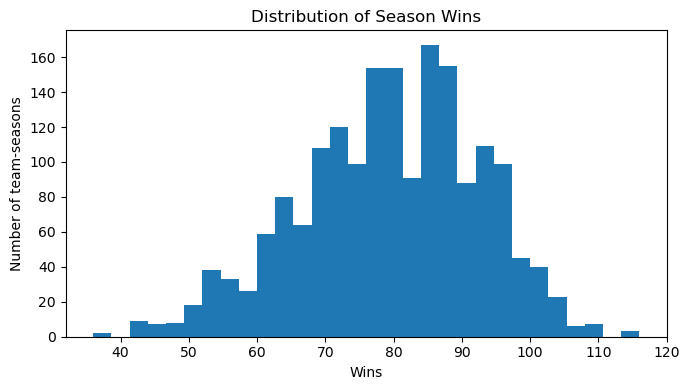

In [18]:
# Plot the distribution of season wins
plt.figure(figsize=(7, 4))
plt.hist(eda["W"], bins=30)
plt.title("Distribution of Season Wins")
plt.xlabel("Wins")
plt.ylabel("Number of team-seasons")
plt.tight_layout()
plt.show()


**Observation:** Season wins are centered around roughly 80 wins, with a fairly wide spread on both sides. The distribution is useful for understanding the target, but raw wins can still be affected by how many games were played in that season.


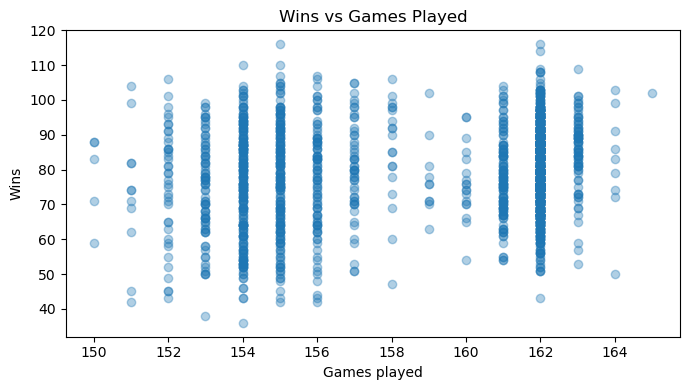

Correlation(W, G) = 0.174


In [19]:
# Check how much season length affects the raw win total
plt.figure(figsize=(7, 4))
plt.scatter(eda["G"], eda["W"], alpha=0.35)
plt.title("Wins vs Games Played")
plt.xlabel("Games played")
plt.ylabel("Wins")
plt.tight_layout()
plt.show()

print(f"Correlation(W, G) = {eda[['W', 'G']].corr().iloc[0, 1]:.3f}")


**Observation:** Season length is not constant across the dataset. This means the same level of team strength can result in different total wins simply because one season has more games. This is why per-game rates and `Win_pct` are useful during EDA.


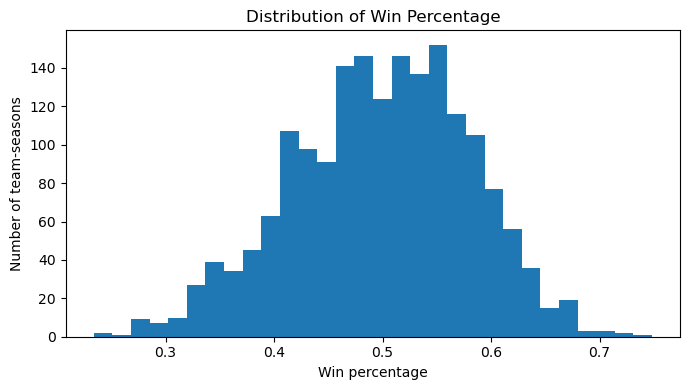

In [20]:
# Plot win percentage for a schedule-length-adjusted view
plt.figure(figsize=(7, 4))
plt.hist(eda["Win_pct"], bins=30)
plt.title("Distribution of Win Percentage")
plt.xlabel("Win percentage")
plt.ylabel("Number of team-seasons")
plt.tight_layout()
plt.show()


**Observation:** The overall shape is similar to the distribution of `W`, which is expected because most seasons have broadly similar schedule lengths. `Win_pct` does not remove variation between strong and weak teams; it mainly makes those teams easier to compare across different season lengths.


## 3. Scoring, run prevention, and winning

A team wins by scoring more runs than it allows. To compare seasons fairly, runs `R` and runs allowed `RA` are assessed on a per-game basis.


In [21]:
# Convert scoring statistics to per-game rates
eda["R_per_game"] = eda["R"] / eda["G"]
eda["RA_per_game"] = eda["RA"] / eda["G"]
eda["RunDiff_per_game"] = (eda["R"] - eda["RA"]) / eda["G"]

run_summary = eda[
    ["R_per_game", "RA_per_game", "RunDiff_per_game", "Win_pct"]
].describe().T

display(run_summary)


,count,mean,std,min,25%,50%,75%,max
R_per_game,1812.0,4.403857,0.647334,2.409091,3.981366,4.393183,4.793919,6.883871
RA_per_game,1812.0,4.401110,0.643558,2.458065,3.972803,4.363080,4.803151,7.685897
RunDiff_per_game,1812.0,0.002747,0.757562,-2.266234,-0.510344,0.024691,0.512987,2.703947
Win_pct,1812.0,0.498295,0.081934,0.233766,0.442160,0.500000,0.555556,0.748387


**Observation:** Converting runs scored and runs allowed to per-game values puts seasons with different numbers of games on the same scale. Run differential per game then summarizes both offense and run prevention in a single measure.


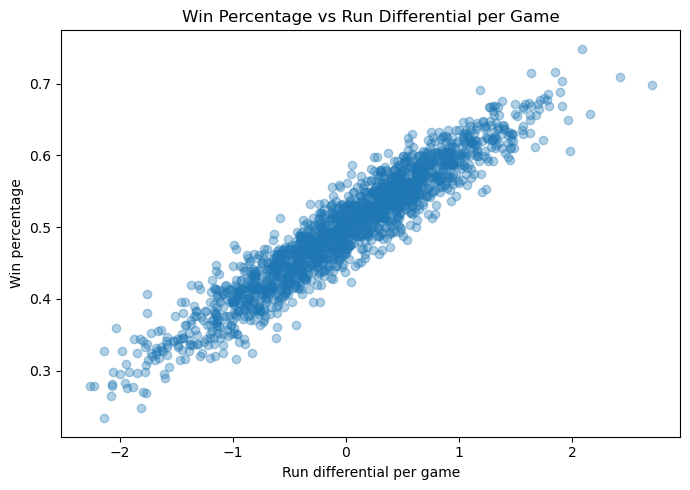

Correlation(Win_pct, RunDiff_per_game) = 0.947


In [22]:
# Visualize the relationship between run differential and winning
plt.figure(figsize=(7, 5))
plt.scatter(eda["RunDiff_per_game"], eda["Win_pct"], alpha=0.35)
plt.title("Win Percentage vs Run Differential per Game")
plt.xlabel("Run differential per game")
plt.ylabel("Win percentage")
plt.tight_layout()
plt.show()

corr = eda[["RunDiff_per_game", "Win_pct"]].corr().iloc[0, 1]
print(f"Correlation(Win_pct, RunDiff_per_game) = {corr:.3f}")


**Observation:** Run differential per game has a very strong positive relationship with winning (`corr ≈ 0.95`). Teams that consistently score more runs than they allow tend to have much higher win percentages.


In [23]:
# Compare the main scoring measures with win percentage
run_relationships = (
    eda[
        ["R_per_game", "RA_per_game", "RunDiff_per_game", "Win_pct"]
    ]
    .corr()["Win_pct"]
    .drop("Win_pct")
    .sort_values(key=np.abs, ascending=False)
)

display(run_relationships.rename("correlation_with_Win_pct"))


RunDiff_per_game    0.947364
R_per_game          0.567223
RA_per_game        -0.544635
Name: correlation_with_Win_pct, dtype: float64

**Observation:** Run differential is the strongest single scoring measure among the three because it combines both offense and defense. However, this does not yet mean it should replace `R/G` and `RA/G`; the separate measures may still contain useful information. That choice will be tested later during feature selection.


## 4. Pythagorean expectation

Pythagorean expectation is a common baseball estimate of expected winning percentage based on runs scored and runs allowed.

It is used here to assess how closely a team's run profile matches its actual results. The formal baseline MAE will be calculated later in `03_baseline.ipynb`.


In [24]:
# Calculate Pythagorean expected win percentage and wins
PYTHAG_EXPONENT = 1.83

r_pow = eda["R"].pow(PYTHAG_EXPONENT)
ra_pow = eda["RA"].pow(PYTHAG_EXPONENT)

eda["Pythag_win_pct"] = r_pow / (r_pow + ra_pow)
eda["Pythag_wins"] = eda["Pythag_win_pct"] * eda["G"]
eda["Pythag_resid_wins"] = eda["W"] - eda["Pythag_wins"]

display(
    eda[
        ["W", "G", "Win_pct", "Pythag_win_pct", "Pythag_wins", "Pythag_resid_wins"]
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
W,1812.0,79.261589,13.127166,36.000000,71.000000,80.000000,89.000000,116.000000
G,1812.0,159.045806,3.745286,150.000000,155.000000,162.000000,162.000000,165.000000
Win_pct,1812.0,0.498295,0.081934,0.233766,0.442160,0.500000,0.555556,0.748387
Pythag_win_pct,1812.0,0.500296,0.077336,0.255903,0.445205,0.502607,0.554353,0.755133
Pythag_wins,1812.0,79.574447,12.370839,38.641330,71.097448,80.423885,88.464296,117.045627
Pythag_resid_wins,1812.0,-0.312857,4.061639,-14.478110,-2.957785,-0.283672,2.351839,13.326213


**Observation:** The Pythagorean estimate tracks actual team performance closely - teams averaged 79.26 actual wins versus 79.57 Pythagorean wins, with the residual averaging only −0.31 wins. The residual standard deviation is about 4.1 wins, and half of all seasons fall between roughly −3.0 and +2.4 wins of the Pythagorean expectation. However, extreme seasons differ by as much as −14.5 to +13.3 wins, suggesting that runs scored and allowed explain most of a team's win total, while a smaller number of teams substantially over- or under-perform their run differential.

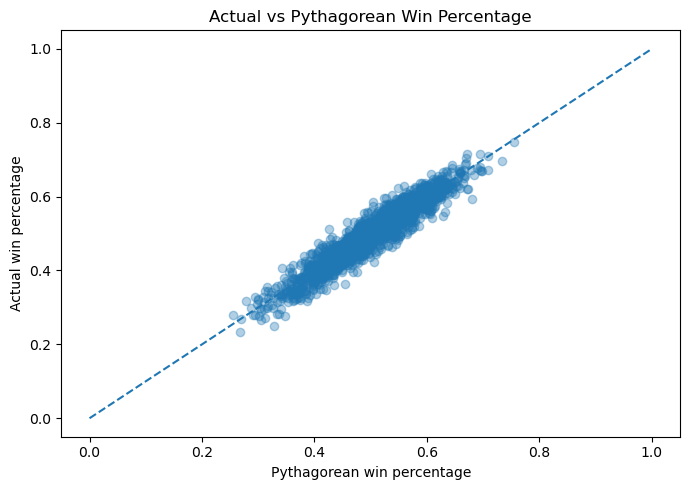

Correlation(Win_pct, Pythag_win_pct) = 0.950


In [25]:
# Compare actual win percentage with Pythagorean expectation
plt.figure(figsize=(7, 5))
plt.scatter(eda["Pythag_win_pct"], eda["Win_pct"], alpha=0.35)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Actual vs Pythagorean Win Percentage")
plt.xlabel("Pythagorean win percentage")
plt.ylabel("Actual win percentage")
plt.tight_layout()
plt.show()

corr = eda[["Pythag_win_pct", "Win_pct"]].corr().iloc[0, 1]
print(f"Correlation(Win_pct, Pythag_win_pct) = {corr:.3f}")


**Observation:** Actual and Pythagorean win percentage are very closely related (`corr ≈ 0.95`). This confirms that scoring and run prevention explain a large part of team success and makes Pythagorean expectation a sensible baseline to test later.


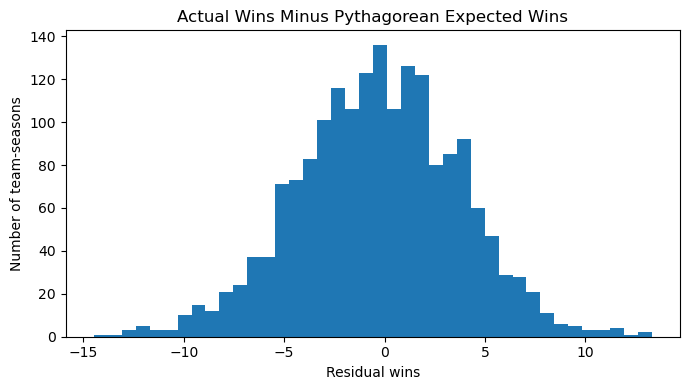

In [26]:
# Look at the distribution of Pythagorean residual wins
plt.figure(figsize=(7, 4))
plt.hist(eda["Pythag_resid_wins"], bins=40)
plt.title("Actual Wins Minus Pythagorean Expected Wins")
plt.xlabel("Residual wins")
plt.ylabel("Number of team-seasons")
plt.tight_layout()
plt.show()


**Observation:** Most teams finish reasonably close to their Pythagorean expectation, while a smaller number are several wins above or below it. These larger residuals are useful edge cases to inspect rather than observations to remove automatically.


## 5. Era effects

Baseball games can change a lot over time. Scoring levels and season lengths can be different across eras, so we should assess how these patterns move by decade.


In [27]:
# Summarize the main statistics by decade
eda["decade"] = (eda["yearID"] // 10 * 10).astype(int)

decade_summary = (
    eda.groupby("decade", as_index=False)
    .agg(
        team_seasons=("ID", "size"),
        avg_games=("G", "mean"),
        avg_runs_per_game=("R_per_game", "mean"),
        avg_runs_allowed_per_game=("RA_per_game", "mean"),
        avg_win_pct=("Win_pct", "mean"),
    )
    .sort_values("decade")
)

display(decade_summary)


,decade,team_seasons,avg_games,avg_runs_per_game,avg_runs_allowed_per_game,avg_win_pct
0,1900,73,155.082192,3.620158,3.576325,0.493858
1,1910,101,155.366337,3.944296,4.029228,0.480492
2,1920,130,154.000000,4.811029,4.784765,0.501395
3,1930,119,153.949580,4.984149,4.930856,0.500611
4,1940,116,154.810345,4.292988,4.284417,0.498502
5,1950,136,154.669118,4.471364,4.490750,0.493777
6,1960,153,161.228758,4.033409,3.998566,0.503143
7,1970,202,161.049505,4.152245,4.145356,0.500756
8,1980,184,161.929348,4.293032,4.325539,0.495199
9,1990,187,161.957219,4.652037,4.648045,0.500270


**Observation:** Average scoring and season length are not constant across decades. This confirms that the dataset covers different baseball environments, so raw totals from one era are not always directly comparable with another.


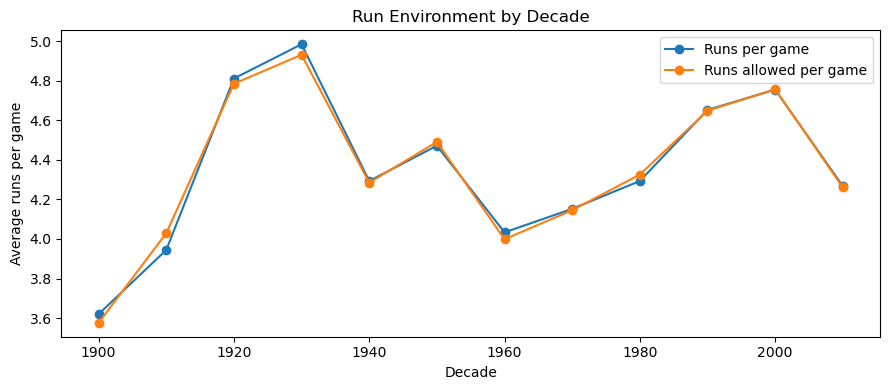

In [28]:
# Plot how the run environment changes over time
plt.figure(figsize=(9, 4))
plt.plot(
    decade_summary["decade"],
    decade_summary["avg_runs_per_game"],
    marker="o",
    label="Runs per game",
)
plt.plot(
    decade_summary["decade"],
    decade_summary["avg_runs_allowed_per_game"],
    marker="o",
    label="Runs allowed per game",
)
plt.title("Run Environment by Decade")
plt.xlabel("Decade")
plt.ylabel("Average runs per game")
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** The scoring environment clearly moves over time rather than staying at one fixed level. This supports testing rate-based or era-adjusted features in the next phase.


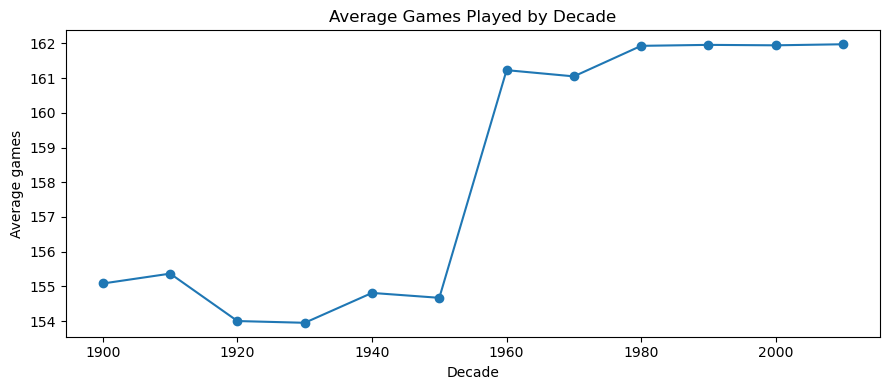

In [29]:
# Plot changes in average season length by decade
plt.figure(figsize=(9, 4))
plt.plot(
    decade_summary["decade"],
    decade_summary["avg_games"],
    marker="o",
)
plt.title("Average Games Played by Decade")
plt.xlabel("Decade")
plt.ylabel("Average games")
plt.tight_layout()
plt.show()


**Observation:** Average games played also changes across baseball history. This is another reason not to rely only on season totals when comparing teams from different periods. Confirming that we should use `/G` features during training and prediction.

## 6. Relationships among the raw baseball statistics

Many baseball statistics describe related parts of team performance, so some of them are likely to be strongly correlated.

This is useful for understanding which variables carry similar information and why regularization may help later.


In [30]:
# Check how the main raw statistics relate to wins
candidate_raw = [
    "R", "RA", "H", "HR", "BB", "SO",
    "ERA", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP",
]

candidate_raw = [c for c in candidate_raw if c in eda.columns]

corr_with_targets = (
    eda[candidate_raw + ["W", "Win_pct"]]
    .corr()
    .loc[candidate_raw, ["W", "Win_pct"]]
)

corr_with_targets["max_abs_corr"] = (
    corr_with_targets[["W", "Win_pct"]].abs().max(axis=1)
)

display(
    corr_with_targets
    .sort_values("max_abs_corr", ascending=False)
    .drop(columns="max_abs_corr")
)


,W,Win_pct
R,0.574881,0.566337
RA,-0.511464,-0.535300
ERA,-0.415615,-0.444322
H,0.404025,0.391955
HA,-0.370401,-0.393388
BB,0.359106,0.337326
BBA,-0.302971,-0.330336
FP,0.320268,0.233492
HR,0.318478,0.236694
E,-0.304817,-0.223284


**Observation:** Runs scored `R` has the strongest positive relationship with winning, while runs allowed `RA` and `ERA` show the strongest negative relationships. Offensive measures such as `R`, `H`, `BB`, and `HR` generally move in the expected positive direction, while run-prevention measures such as `RA`, `ERA`, `HA`, and `BBA` move negatively. Some of these metrics represent related aspects of team performance and may therefore contain overlapping predictive information; this need to be verified using the feature correlation matrix.


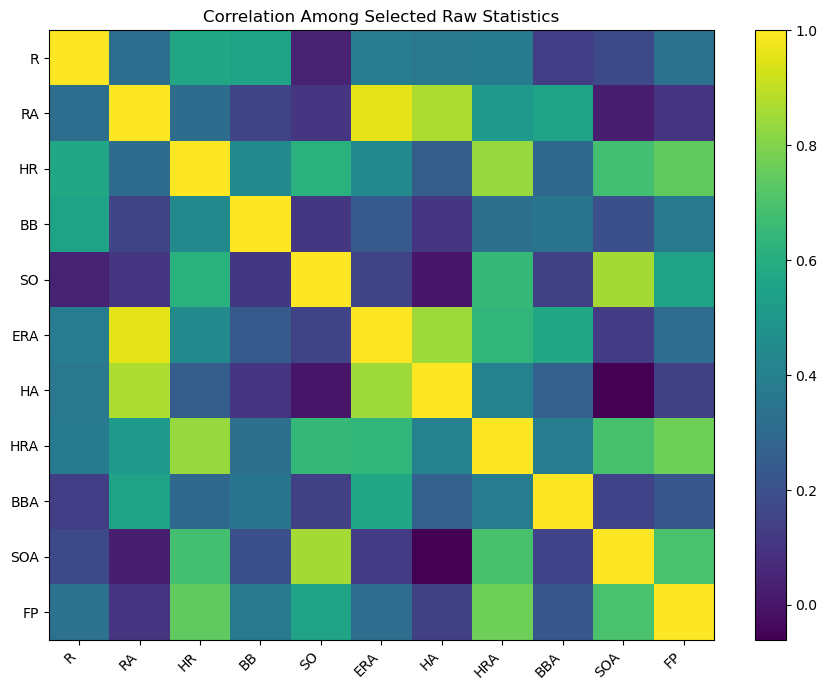

In [31]:
# Visualize correlation among selected raw features
heatmap_cols = [
    c for c in [
        "R", "RA", "HR", "BB", "SO",
        "ERA", "HA", "HRA", "BBA", "SOA", "FP"
    ]
    if c in eda.columns
]

corr_matrix = eda[heatmap_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix.values, aspect="auto")
plt.colorbar()
plt.xticks(
    range(len(heatmap_cols)),
    heatmap_cols,
    rotation=45,
    ha="right",
)
plt.yticks(range(len(heatmap_cols)), heatmap_cols)
plt.title("Correlation Among Selected Raw Statistics")
plt.tight_layout()
plt.show()


**Observation:** Several raw statistics are strongly correlated, particularly `RA–ERA–HA` and `SO–SOA`, indicating substantial overlap in the information captured by these features. This creates a risk of multicollinearity in linear models, where individual coefficients may become unstable or difficult to interpret. Regularized models such as Ridge or Lasso, along with feature selection, should therefore be considered instead of relying only on unrestricted linear regression.

## 7. Seasons that deviate from Pythagorean expectation

Some teams finish with noticeably more or fewer wins than their run differential would suggest.

These seasons are worth looking at because they show where Pythagorean expectation does not fully explain the final result.


In [33]:
# Find seasons with the largest Pythagorean residuals
outliers = (
    eda.assign(abs_pythag_resid=eda["Pythag_resid_wins"].abs())
    .sort_values("abs_pythag_resid", ascending=False)
)

show_cols = [
    c for c in [
        "ID", "yearID", "teamID", "franchID",
        "G", "W", "R", "RA",
        "Win_pct", "Pythag_win_pct",
        "Pythag_wins", "Pythag_resid_wins"
    ]
    if c in outliers.columns
]

display(outliers[show_cols].head(15).reset_index(drop=True))


,ID,yearID,teamID,franchID,G,W,R,RA,Win_pct,Pythag_win_pct,Pythag_wins,Pythag_resid_wins
0,1365,1993,NYN,NYM,162,59,672,744,0.364198,0.453569,73.478110,-14.478110
1,397,1905,CHN,BOS,155,92,667,442,0.593548,0.679834,105.374259,-13.374259
2,848,1905,DET,COL,154,79,512,602,0.512987,0.426453,65.673787,13.326213
3,2183,2016,TEX,TEX,162,95,765,757,0.586420,0.504809,81.779116,13.220884
4,1785,1986,PIT,PIT,162,64,663,700,0.395062,0.475176,76.978469,-12.978469
5,613,1907,CIN,CHW,156,66,526,519,0.423077,0.506129,78.956120,-12.956120
6,1713,1911,PIT,PHI,155,85,744,557,0.548387,0.629423,97.560508,-12.560508
7,1481,2004,NYA,NYY,162,101,897,808,0.623457,0.547661,88.721045,12.278955
8,102,1935,BSN,ATL,153,38,575,852,0.248366,0.327484,50.105070,-12.105070
9,1783,1984,PIT,PIT,162,75,615,567,0.462963,0.537109,87.011730,-12.011730


**Observation:** The largest Pythagorean residuals are substantial, with some teams finishing about 11–14 wins above or below the total implied by their runs scored and runs allowed. e.g., in 2016 `TEX` won about 13 more games than expected, while in 1993 `NYN` won about 14 fewer. These records appear to be valid team-seasons rather than data errors, showing that run differential alone does not fully explain season wins. They are therefore retained in the dataset.

In [34]:
# Summarize the size of the largest residuals
resid_quantiles = (
    eda["Pythag_resid_wins"]
    .abs()
    .quantile([0.90, 0.95, 0.99])
    .rename("absolute_residual_wins")
)

display(resid_quantiles)


0.90     6.666195
0.95     7.995257
0.99    11.244491
Name: absolute_residual_wins, dtype: float64

**Observation:** Absolute Pythagorean residuals above ~6.7 wins fall in the top 10%, above 8.0 wins in the top 5%, and above 11.2 wins in the top 1%. This confirms that deviations of 11–14 wins are genuinely unusual, but they represent rare baseball outcomes rather than obvious data-quality errors, so these seasons are retained.


## 8. EDA findings

The main points from the EDA are:

1. Season length varies across the dataset. `Win_pct` is useful for comparing seasons, but the modelling target remains total wins (`W`).
2. Run differential per game has a very strong relationship with winning and is an important candidate feature. Whether it should replace or complement `R/G` and `RA/G` will be tested later.
3. Pythagorean expectation closely tracks actual results and provides a natural baseball baseline.
4. The scoring environment and season length change over time, so per-game and era-adjusted features are worth testing.
5. Many raw baseball statistics are correlated, which supports evaluating regularized models.
6. Large Pythagorean residuals appear to be genuine baseball variation rather than obvious bad records.
7. `teamID` and `franchID` are kept for description rather than as model features. Lag features remain excluded because the franchise/year history is not consistently unique.

These observations will guide `02_feature_engineering.ipynb`.
